In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("E-Commerce/raw_ecommerce_sales.csv")
print("Shape:",df.shape)

Shape: (3500, 7)


In [7]:
print("\nColumns:",df.columns)


Columns: Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')


In [8]:
print("\nData Types:\n",df.dtypes)
print("\nMissing Values:\n",df.isnull().sum())


Data Types:
 Order Date       object
Product Name     object
Category         object
Region           object
Quantity          int64
Sales             int64
Profit          float64
dtype: object

Missing Values:
 Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64


In [9]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df.dtypes

Order Date      datetime64[ns]
Product Name            object
Category                object
Region                  object
Quantity                 int64
Sales                    int64
Profit                 float64
dtype: object

In [15]:
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month
df["Month Name"]=df["Order Date"].dt.month_name()

df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Year,Month,Month Name
0,2024-12-31,Printer,Office,North,4,3640,348.93,2024,12,December
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,2022,11,November
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,2022,5,May
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,2024,3,March
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,2022,9,September


In [17]:
df[df["Profit"]<0].head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Year,Month,Month Name


In [18]:
print("Minimum Profit:", df["Profit"].min())

Minimum Profit: 6.97


In [19]:
print("Maximum Profit:", df["Profit"].max())

Maximum Profit: 2946.93


In [20]:
## Calculated Fields

In [21]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

In [22]:
profit_margin=(total_profit/total_sales)*100
print("Overall Profit Margin: {: .2f}%".format(profit_margin))

Overall Profit Margin:  17.29%


In [23]:
## Sales & Profit by region

In [25]:
regional_sales_profit=df.groupby("Region")[["Sales","Profit"]].sum()
regional_sales_profit

,Sales,Profit
Region,,
East,2675110,464888.46
North,2488773,426314.75
South,2659548,458103.27
West,2844450,495358.73


In [26]:
df["Year"].unique()

array([2024, 2022, 2023], dtype=int32)

In [27]:
## Sales and Profit by Year

In [28]:
yearly_sales_profit = df.groupby("Year")[["Sales","Profit"]].sum()
yearly_sales_profit

,Sales,Profit
Year,,
2022,3255970,572856.98
2023,3786592,666866.42
2024,3625319,604941.81


In [29]:
## Sales And Profit by Category

In [30]:
category_sales_profit = df.groupby("Category")[["Sales","Profit"]].sum()
category_sales_profit

,Sales,Profit
Category,,
Accessories,4247591,736084.74
Electronics,5326074,923185.59
Office,1094216,185394.88


In [31]:
## Top 10 Products

In [32]:
top_products= df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Monitor       1876
Smartwatch    1807
Camera        1795
Mouse         1753
Printer       1734
Tablet        1733
Keyboard      1684
Laptop        1658
Smartphone    1617
Headphones    1604
Name: Quantity, dtype: int64

In [33]:
## Data Visualizations

In [34]:
sns.set_style("whitegrid")

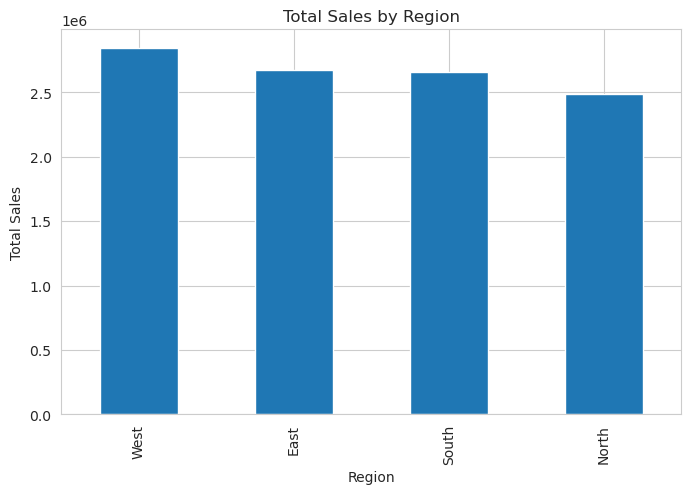

In [36]:
## Sales by Region

sales_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sales_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

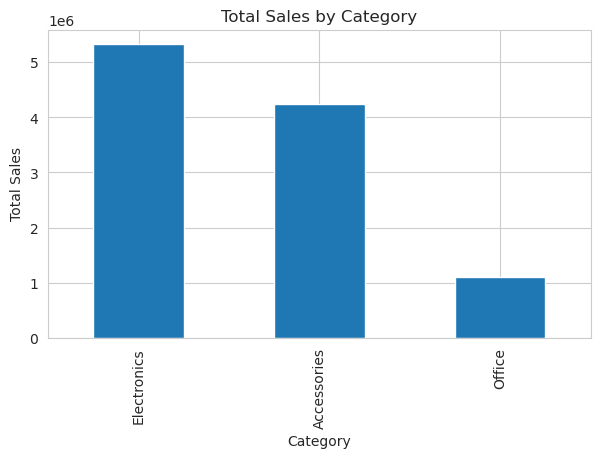

In [39]:
## Sales by Category

sales_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,4))
sales_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [40]:
print(df.columns)

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit', 'Year', 'Month', 'Month Name'],
      dtype='object')


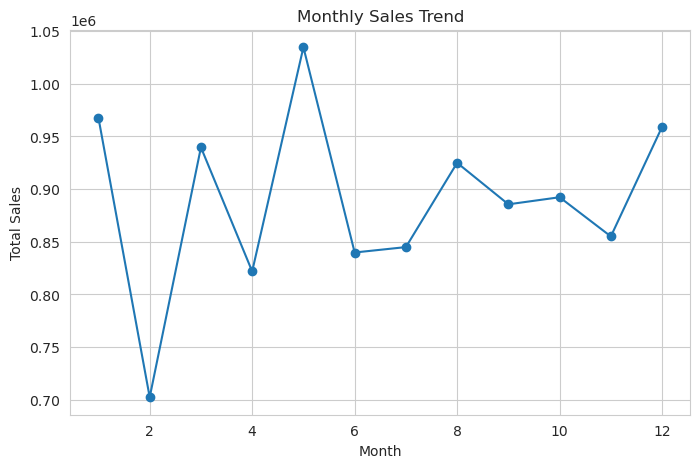

In [41]:
## Monthly Sales Trend
sales_month = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(8,5))
sales_month.plot(kind="line",marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()